In [1]:
import pandas as pd

df = pd.read_csv("../data/Superstore.csv")
df.head()

,order_id,order_date,ship_date,Category,sub_category,Region,Sales,Profit,Quantity
0,CA-2016-152156,2016-11-08,2016-11-11,Furniture,Bookcases,South,261.9600,41.9136,2
1,CA-2016-152156,2016-11-08,2016-11-11,Furniture,Chairs,South,731.9400,219.5820,3
2,CA-2016-138688,2016-06-12,2016-06-16,Office Supplies,Labels,West,14.6200,6.8714,2
3,US-2015-108966,2015-10-11,2015-10-18,Furniture,Tables,South,957.5775,-383.0310,5
4,US-2015-108966,2015-10-11,2015-10-18,Office Supplies,Storage,South,22.3680,2.5164,2


In [2]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [3]:
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year
df['day_of_week'] = df['order_date'].dt.day_name()

In [4]:
df[['Sales','Profit','Quantity']].corr()

,Sales,Profit,Quantity
Sales,1.000000,0.479064,0.200795
Profit,0.479064,1.000000,0.066253
Quantity,0.200795,0.066253,1.000000


In [5]:
monthly = df.groupby(['year','month'])['Sales'].sum().reset_index()

In [6]:
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly = monthly.sort_values('date')

In [7]:
monthly['lag_1'] = monthly['Sales'].shift(1)
monthly['lag_2'] = monthly['Sales'].shift(2)

monthly['rolling_mean_3'] = monthly['Sales'].rolling(3).mean()

In [8]:
monthly = monthly.copy()

In [9]:
monthly = monthly.dropna().copy()

In [10]:
train = monthly.iloc[:-6]   # all except last 6 months
test = monthly.iloc[-6:]    # last 6 months

In [11]:
features = ['month', 'lag_1', 'lag_2', 'rolling_mean_3']

X_train = train[features]
y_train = train['Sales']

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
monthly = monthly.copy()

In [13]:
monthly = monthly.dropna().copy()

In [14]:
X_test = test[features]

test = test.copy()
test['predicted_sales'] = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['Sales'], test['predicted_sales'])
print("MAE:", mae)

MAE: 12414.730184999993


In [16]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['Sales'], test['predicted_sales']))
print("RMSE:", rmse)

RMSE: 17253.90317745547


In [17]:
mape = np.mean(np.abs((test['Sales'] - test['predicted_sales']) / test['Sales'])) * 100
print("MAPE:", mape)

MAPE: 13.721792607769734


In [18]:
test['error'] = test['Sales'] - test['predicted_sales']

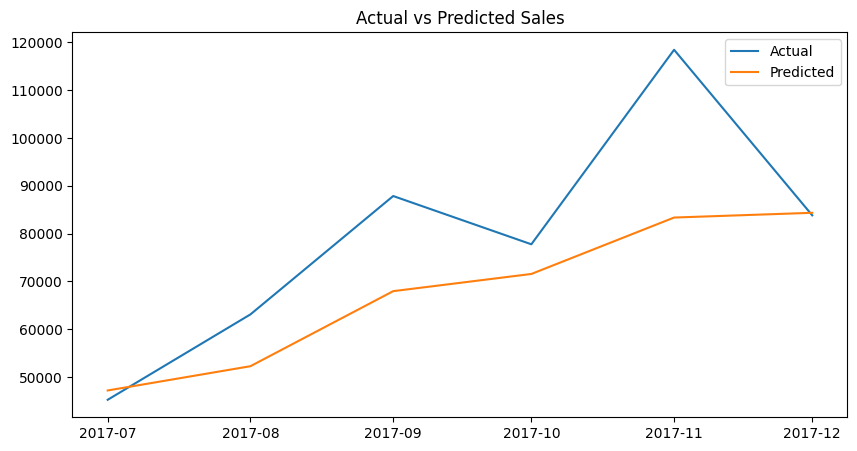

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test['date'], test['Sales'], label='Actual')
plt.plot(test['date'], test['predicted_sales'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [20]:
test.to_csv("final_forecast.csv", index=False)

In [24]:
prophet_df = monthly[['date', 'Sales']].copy()

prophet_df.columns = ['ds', 'y']

In [25]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
00:45:29 - cmdstanpy - INFO - Chain [1] start processing
00:45:30 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
future = model.make_future_dataframe(periods=6, freq='M')

In [27]:
forecast = model.predict(future)

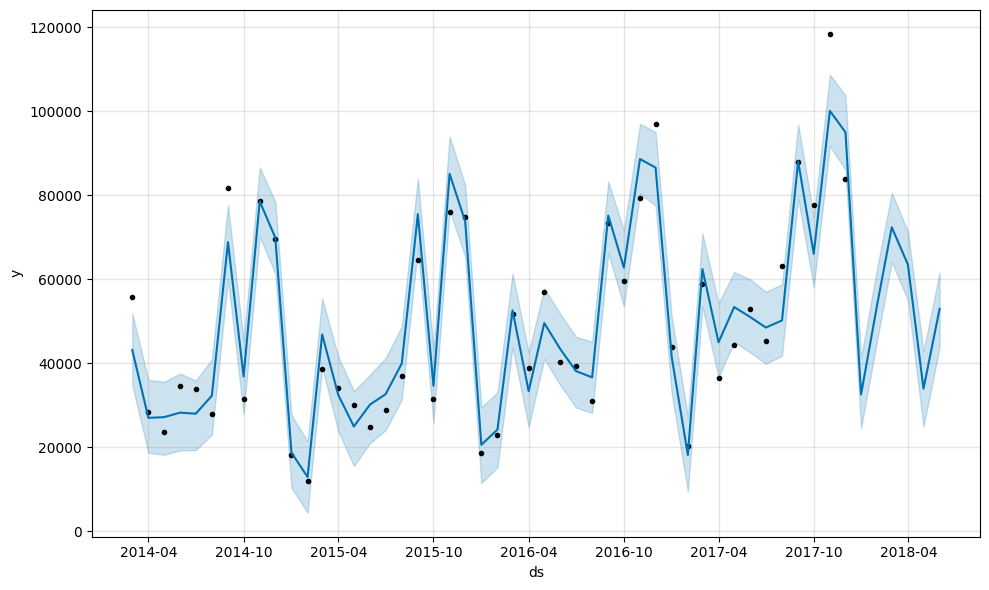

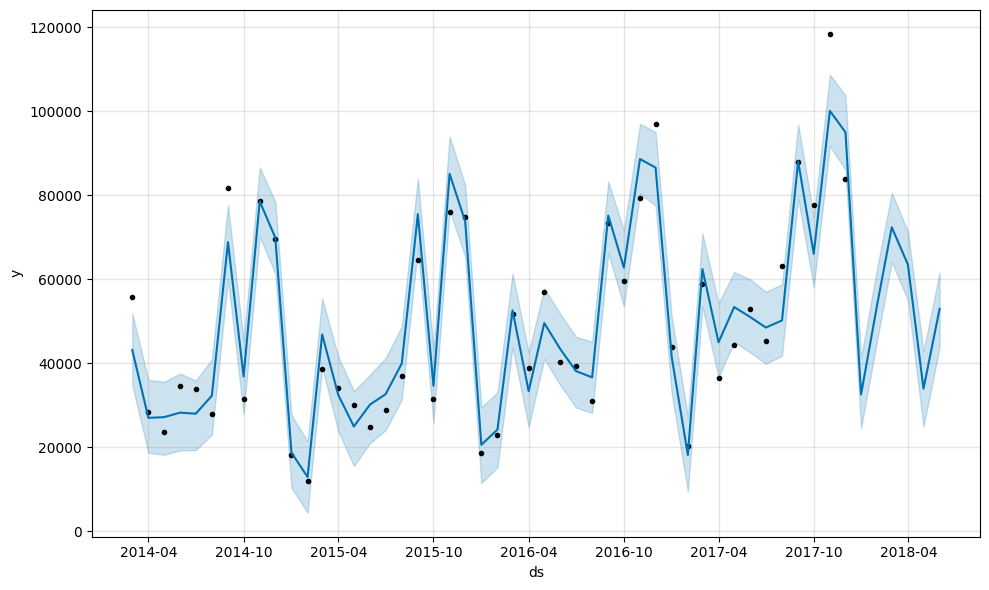

In [29]:
model.plot(forecast)

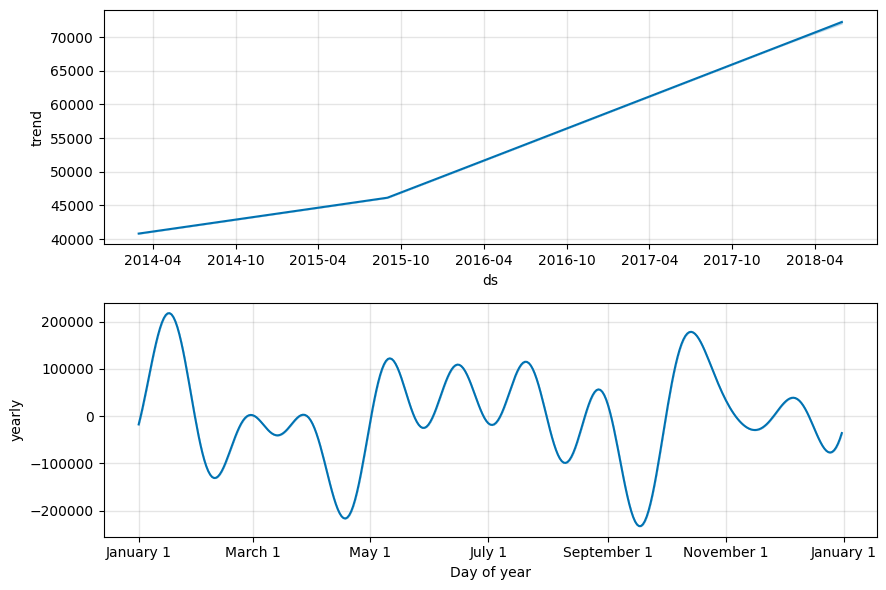

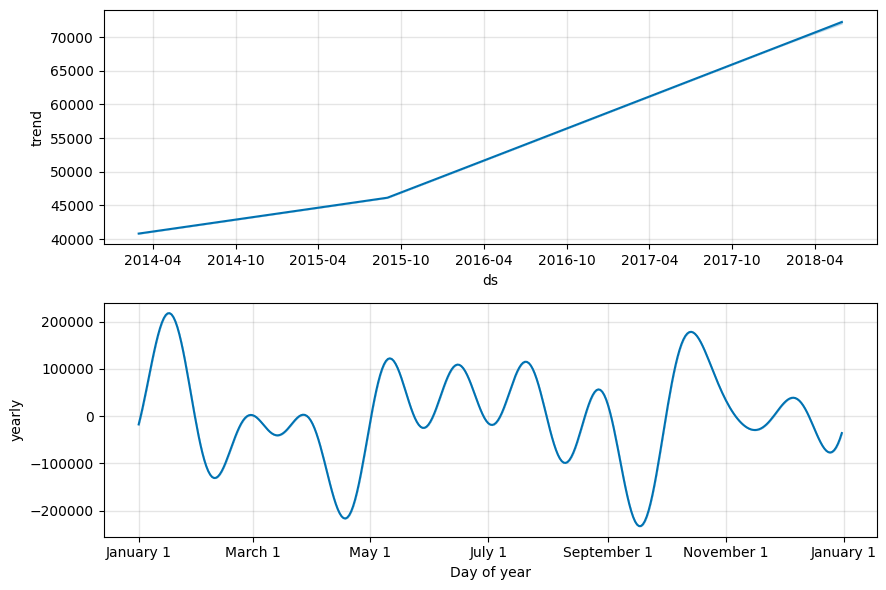

In [30]:
model.plot_components(forecast)

In [32]:
from sklearn.metrics import mean_absolute_error

merged = forecast[['ds', 'yhat']].merge(
    prophet_df, on='ds', how='inner'
)

mae_prophet = mean_absolute_error(merged['y'], merged['yhat'])

print("Prophet MAE:", mae_prophet)

Prophet MAE: 5273.249737794578


In [ ]:
forecast.to_csv("prophet_forecast.csv", index=False)